<a href="https://colab.research.google.com/github/Tejal-singhh/OIBSIP/blob/main/DataAnalytics-Level2-WineQualityPrediction/Tejalsingh_L2Task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving WineQT.csv to WineQT.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("WineQT.csv")
df = df.drop('Id', axis=1)
print("Shape:", df.shape)
df.info()

Shape: (1143, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 107.3 KB


## Load Dataset

Loaded the Wine Quality dataset containing 1,143 wines described by 11 physicochemical properties (e.g. fixed acidity, volatile acidity, residual sugar, pH, alcohol) plus a `quality` score, which is the target variable. The `Id` column was dropped since it is only a row identifier with no predictive value. All features are numeric.

Null values: 0
Duplicate rows: 125

quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64


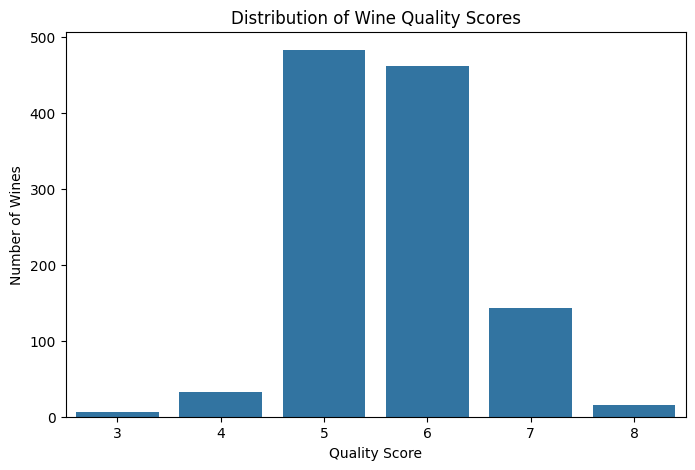

In [3]:
print("Null values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print()
print(df['quality'].value_counts().sort_index())

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='quality')
plt.title('Distribution of Wine Quality Scores')
plt.xlabel('Quality Score')
plt.ylabel('Number of Wines')
plt.show()

In [4]:
before = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
after = df.shape[0]

print("Rows before:", before)
print("Rows after:", after)
print("Duplicates removed:", before - after)
print()
print(df['quality'].value_counts().sort_index())

Rows before: 1143
Rows after: 1018
Duplicates removed: 125

quality
3      6
4     33
5    433
6    409
7    122
8     15
Name: count, dtype: int64


## Class Distribution of Quality Scores & Duplicate Handling

There are no missing values, but **125 duplicate rows** were found (visible only after dropping the `Id` column, which had been making every row look unique). Because identical rows could appear in both the training and test sets and artificially inflate model scores (data leakage), the duplicates were removed, leaving 1,018 wines.

The remaining quality scores range from 3 to 8 and are heavily concentrated in the middle: score 5 (433 wines, ~43%) and score 6 (409 wines, ~40%) make up over 80% of the data. Score 7 has 122 wines (~12%), while the extremes are very rare: score 4 has 33 (~3%), score 8 has 15 (~1.5%), and score 3 has just 6 (~0.6%). This is a strongly imbalanced classification problem, which we discuss in detail before modelling.

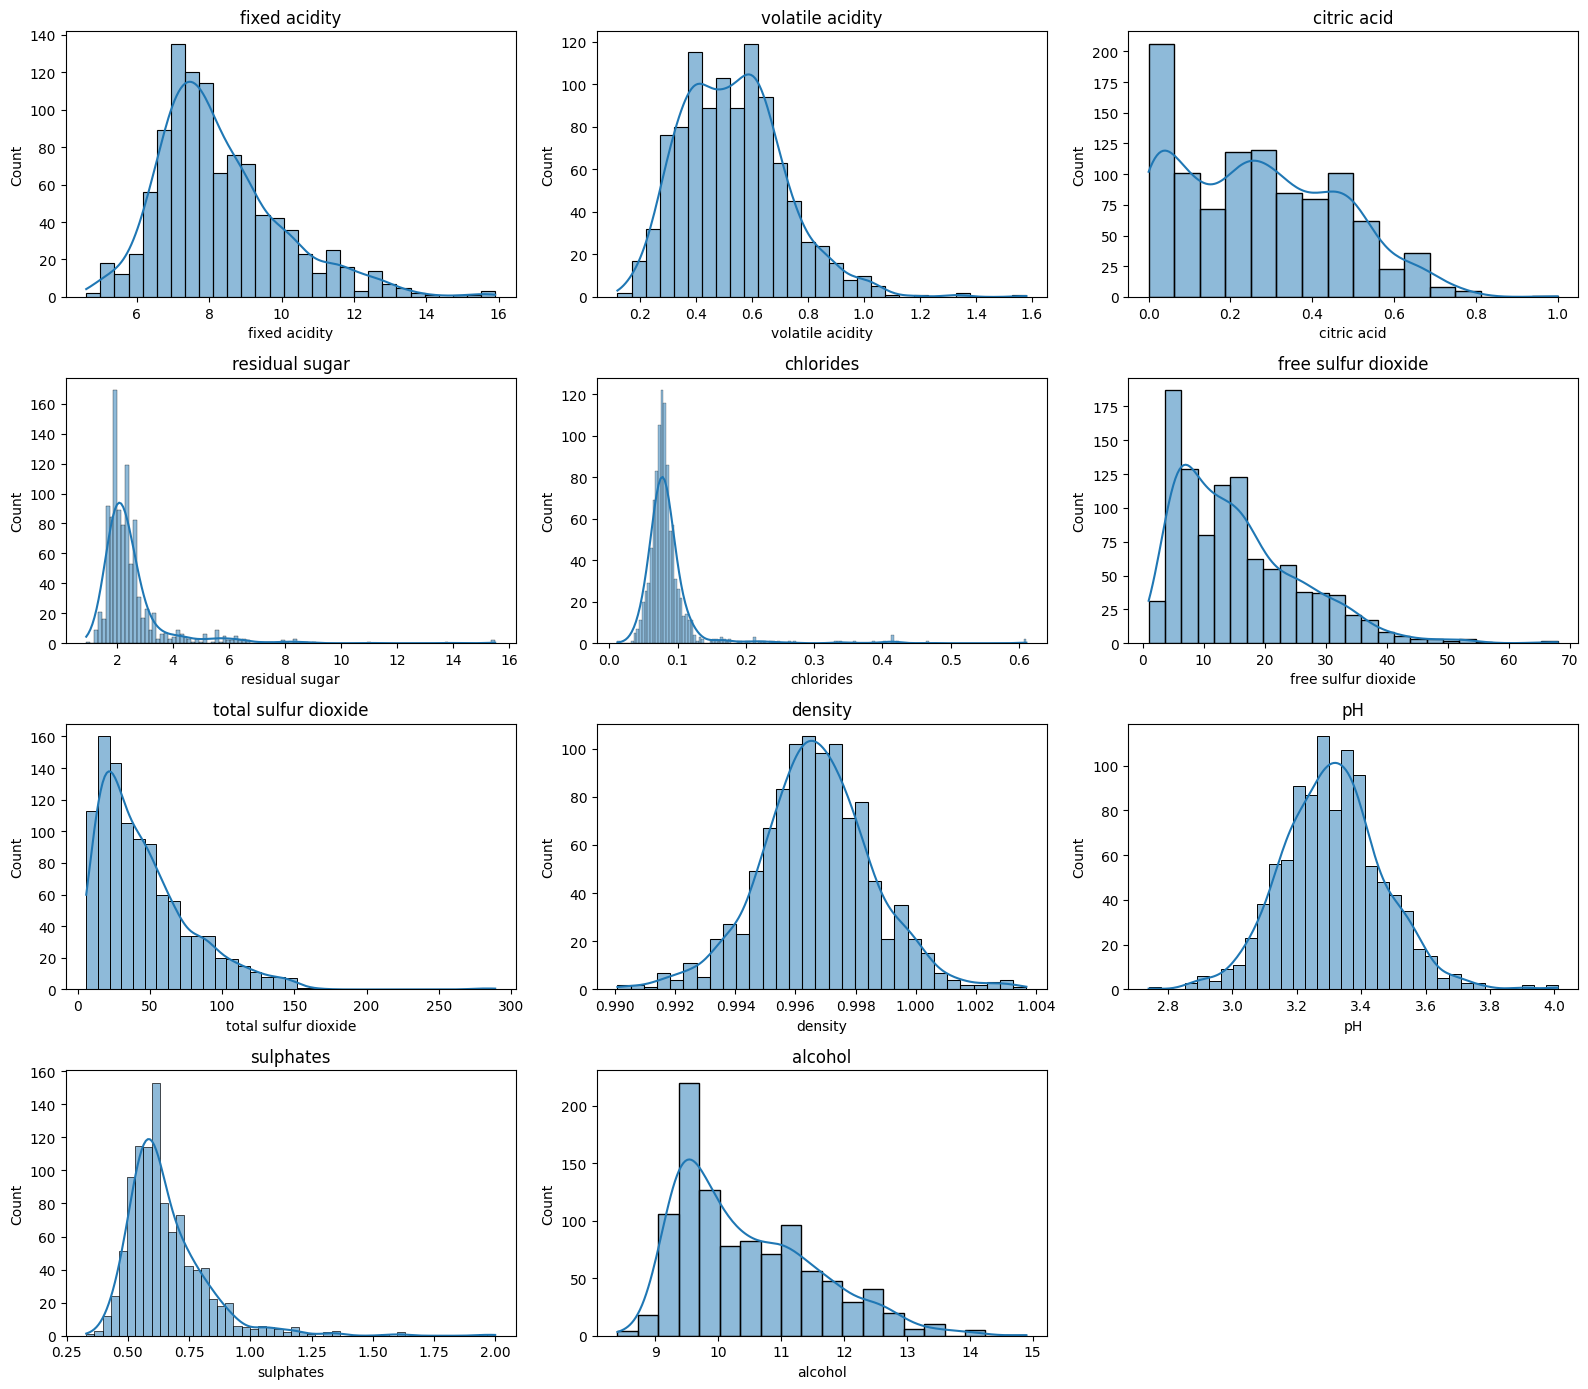

In [5]:
features = df.columns.drop('quality')

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

## Distribution of Chemical Features

Most features are **right-skewed** (a long tail of high values). The most extreme are `chlorides` (skew 5.9), `residual sugar` (4.4) and `sulphates` (2.4): most wines have low values, but a few have very high ones, which points to outliers. `total sulfur dioxide`, `free sulfur dioxide` and `fixed acidity` are moderately skewed. `density` and `pH` are almost symmetric and bell-shaped. Since Random Forest is insensitive to feature scale but SGD and SVC are not, we will need to standardise the features before training those two models.
Two other details stand out: `citric acid` has a large spike at exactly 0 (many wines contain none) followed by several smaller bumps rather than a single smooth peak, and `alcohol` is concentrated around 9-10% with a gradual tail up to about 14%.

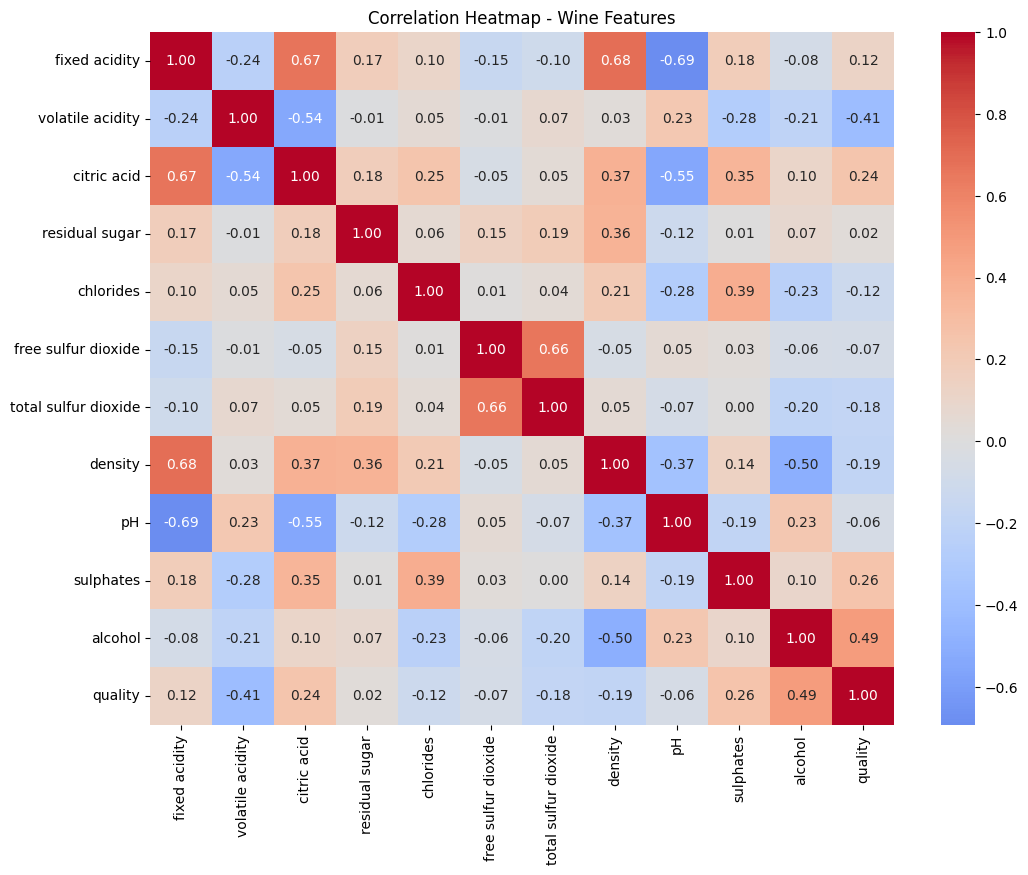

In [6]:
plt.figure(figsize=(12, 9))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap - Wine Features')
plt.show()

## Correlation Analysis

**Correlation with quality:** `alcohol` is the strongest positive predictor (+0.49), followed by `sulphates` (+0.26) and `citric acid` (+0.24). `volatile acidity` is the strongest negative one (-0.41): wines with more volatile acidity (which gives a vinegar-like taste) tend to score lower. `density` (-0.19) and `total sulfur dioxide` (-0.18) also have weak negative relationships, while `residual sugar` (+0.02) and `pH` (-0.06) are almost unrelated to quality.

**Correlation between features:** Some features are strongly related to each other, such as `fixed acidity` with `density` (+0.68), `pH` (-0.69) and `citric acid` (+0.67), and `free` with `total sulfur dioxide` (+0.66). This overlap is expected chemically and is not a problem for tree-based models like Random Forest, but it is worth knowing about for SGD and SVC.

## Class Imbalance Discussion

Yes, certain quality scores are heavily underrepresented. Scores 5 and 6 make up over 80% of the data, while score 4 has only 33 wines (~3%), score 8 has 15 (~1.5%), and score 3 has just 6 (~0.6%).

**How this affects modelling:**
1. **Bias toward the majority classes:** a model can achieve a decent accuracy simply by predicting 5 or 6 for almost every wine (always guessing 5 would already be right ~43% of the time), while never learning what a genuinely poor or excellent wine looks like.
2. **Accuracy becomes misleading:** a high overall accuracy can hide a model that completely fails on the rare classes, so we must also look at per-class precision and recall in the classification report.
3. **Too few examples to learn from:** with only 6 wines of quality 3, the model has almost nothing to learn from, and after a train/test split there would be only 1 in the test set, making its evaluation meaningless.

**How we will address it:** (a) group the quality scores into fewer, better-populated classes (next step), (b) use a stratified train/test split so every class keeps the same proportion in both sets, and (c) use `class_weight='balanced'` in the models so mistakes on rare classes are penalised more heavily.

quality_group
Low       472
Medium    409
High      137
Name: count, dtype: int64


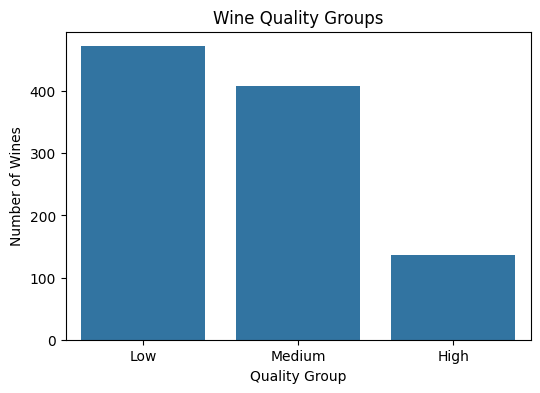

In [7]:
def bin_quality(q):
    if q <= 5:
        return 'Low'
    elif q == 6:
        return 'Medium'
    else:
        return 'High'

df['quality_group'] = df['quality'].apply(bin_quality)

print(df['quality_group'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='quality_group', order=['Low', 'Medium', 'High'])
plt.title('Wine Quality Groups')
plt.xlabel('Quality Group')
plt.ylabel('Number of Wines')
plt.show()

## Feature Engineering: Binning Quality Scores

The original 6-class target (scores 3-8) is too imbalanced to model well, since scores 3, 4 and 8 have only 6, 33 and 15 wines. The scores were therefore grouped into **3 classes**: **Low** (3-5, 472 wines, ~46%), **Medium** (6, 409 wines, ~40%) and **High** (7-8, 137 wines, ~13%).

**Why 3 classes instead of binary (good/bad):** a 3-class target keeps the ordering information (low < medium < high) and gives a more useful prediction than a simple pass/fail, while still giving every class enough samples (at least 137) to learn from and to evaluate reliably. The trade-off is that the Medium class sits between the other two, so its wines overlap most with both neighbours and will likely be the hardest to classify. The High class remains the smallest (~13%), so per-class recall for it deserves close attention in the evaluation.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(['quality', 'quality_group'], axis=1)
y = df['quality_group']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])
print("\nTrain class proportions:\n", y_train.value_counts(normalize=True).round(3))
print("\nTest class proportions:\n", y_test.value_counts(normalize=True).round(3))

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train size: 814
Test size: 204

Train class proportions:
 quality_group
Low       0.463
Medium    0.402
High      0.135
Name: proportion, dtype: float64

Test class proportions:
 quality_group
Low       0.466
Medium    0.402
High      0.132
Name: proportion, dtype: float64


## Train/Test Split with Stratification

The data was split 80/20 into a training set (814 wines) and a test set (204 wines). A **stratified** split (`stratify=y`) was used so that the Low/Medium/High proportions are preserved in both sets (~46% / 40% / 13%). Without stratification, a random split could under-represent the small High class in the test set and make its evaluation unreliable.

Both the original `quality` column and the new `quality_group` column were excluded from the input features to prevent target leakage. The features were then standardised with `StandardScaler`, fitted on the training set only and applied to the test set, because SGD and SVC are sensitive to feature scale and fitting on the test data would leak information.

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
sgd = SGDClassifier(class_weight='balanced', random_state=42)
svc = SVC(class_weight='balanced', random_state=42)

rf.fit(X_train_scaled, y_train)
sgd.fit(X_train_scaled, y_train)
svc.fit(X_train_scaled, y_train)

rf_pred = rf.predict(X_test_scaled)
sgd_pred = sgd.predict(X_test_scaled)
svc_pred = svc.predict(X_test_scaled)

print("All 3 models trained.")

All 3 models trained.


## Model Training

Three classifiers were trained on the same scaled training set (814 wines) for a fair comparison:
- **Random Forest:** an ensemble of 200 decision trees that vote on the class; handles non-linear relationships and feature interactions well.
- **SGD Classifier:** a fast linear model trained with stochastic gradient descent; simple and scalable, but limited to linear decision boundaries.
- **Support Vector Classifier (SVC):** finds the maximum-margin boundary between classes and, with the default RBF kernel, can model non-linear boundaries.

All three use `class_weight='balanced'` so that errors on the rarer High and Medium classes are penalised more heavily, addressing the class imbalance identified earlier.

===== Random Forest =====
Accuracy: 0.6569
              precision    recall  f1-score   support

         Low       0.69      0.83      0.75        95
      Medium       0.60      0.51      0.55        82
        High       0.68      0.48      0.57        27

    accuracy                           0.66       204
   macro avg       0.66      0.61      0.62       204
weighted avg       0.65      0.66      0.65       204

===== SGD =====
Accuracy: 0.5882
              precision    recall  f1-score   support

         Low       0.67      0.74      0.70        95
      Medium       0.50      0.40      0.45        82
        High       0.52      0.63      0.57        27

    accuracy                           0.59       204
   macro avg       0.56      0.59      0.57       204
weighted avg       0.58      0.59      0.58       204

===== SVC =====
Accuracy: 0.6225
              precision    recall  f1-score   support

         Low       0.69      0.75      0.72        95
      Medium       0

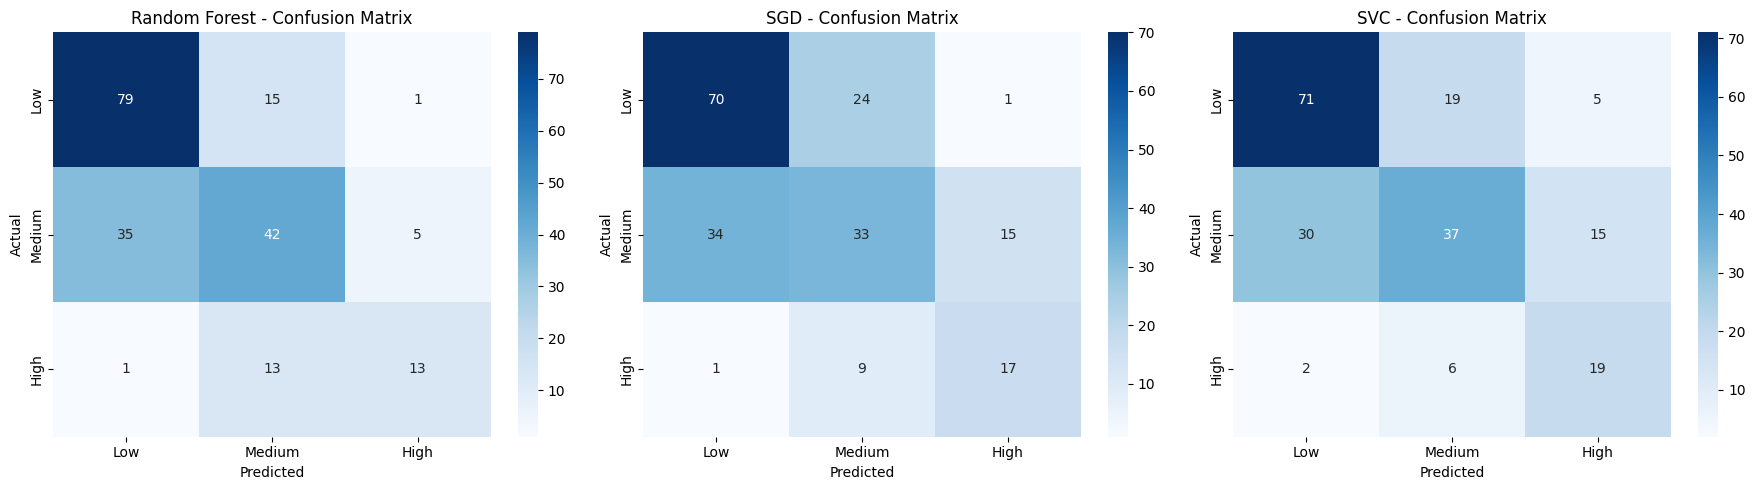

In [10]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

labels = ['Low', 'Medium', 'High']
models = {'Random Forest': rf_pred, 'SGD': sgd_pred, 'SVC': svc_pred}

for name, pred in models.items():
    print(f"===== {name} =====")
    print("Accuracy:", round(accuracy_score(y_test, pred), 4))
    print(classification_report(y_test, pred, labels=labels))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, pred) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, pred, labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(f'{name} - Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

## Model Evaluation

| Model | Accuracy | High recall | Medium recall | Low recall |
|---|---|---|---|---|
| Random Forest | 65.7% | 0.48 | 0.51 | 0.83 |
| SGD | 58.8% | 0.63 | 0.40 | 0.74 |
| SVC | 62.3% | 0.70 | 0.45 | 0.75 |

- **Random Forest** has the highest accuracy and the best balance between precision and recall. It is strongest on the Low class (recall 0.83) but misses about half of the High wines (recall 0.48).
- **SGD** is the weakest overall (58.8%). As a linear model it struggles most with the Medium class (recall 0.40, F1 0.45), which overlaps with both neighbours.
- **SVC** sits in between. It finds the most High-quality wines (recall 0.70), but at the cost of lower precision (0.49), meaning many wines it labels High are not.
- **Medium is the hardest class for every model**, as expected: wines rated 6 have chemistry that overlaps with both Low and High wines, so the confusion matrices show most errors happening between neighbouring classes rather than between Low and High.
- The test set contains only 27 High wines, so the High-class scores are based on a small sample and should be read as indicative rather than precise.

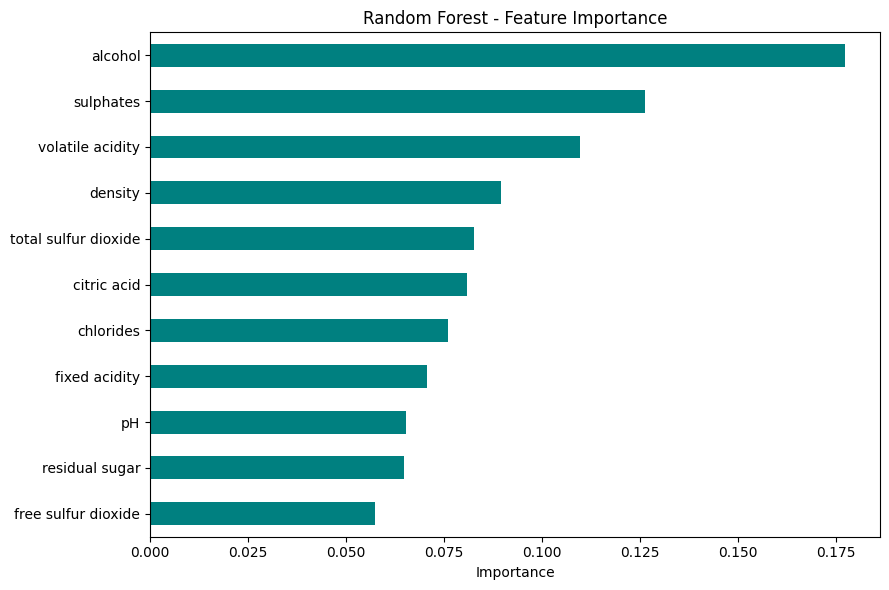

,0
alcohol,0.177296
sulphates,0.126149
volatile acidity,0.109602
density,0.089430
total sulfur dioxide,0.082580
citric acid,0.080847
chlorides,0.076083
fixed acidity,0.070614
pH,0.065258
residual sugar,0.064830


In [11]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(9, 6))
importances.plot(kind='barh', color='teal')
plt.title('Random Forest - Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

importances.sort_values(ascending=False)

## Feature Importance (Random Forest)

`alcohol` is clearly the most important feature (0.177), well ahead of `sulphates` (0.126) and `volatile acidity` (0.110). These three are the top drivers of the predicted quality group. This agrees with the correlation analysis, where alcohol (+0.49), volatile acidity (-0.41) and sulphates (+0.26) also had the strongest relationships with quality.

The remaining features contribute more evenly, between 0.057 and 0.089. `free sulfur dioxide` (0.057) is the least important, while `density` and `total sulfur dioxide` are the most useful of the middle group. `residual sugar` and `pH`, which had almost no linear correlation with quality, still carry some importance (0.065 each), because Random Forest can also pick up non-linear patterns and feature interactions that a correlation coefficient misses.

**Practical meaning:** a winemaker who wants to influence perceived quality should focus first on alcohol level, sulphate content and keeping volatile acidity low.

In [12]:
import time
from sklearn.metrics import precision_score, recall_score, f1_score

results = []
model_objs = {'Random Forest': rf, 'SGD': sgd, 'SVC': svc}
preds = {'Random Forest': rf_pred, 'SGD': sgd_pred, 'SVC': svc_pred}

for name in model_objs:
    p = preds[name]
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, p),
        'Macro Precision': precision_score(y_test, p, average='macro'),
        'Macro Recall': recall_score(y_test, p, average='macro'),
        'Macro F1': f1_score(y_test, p, average='macro'),
        'Weighted F1': f1_score(y_test, p, average='weighted'),
    })

comparison = pd.DataFrame(results).set_index('Model').round(4)
comparison

,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
Model,,,,,
Random Forest,0.6569,0.6571,0.6084,0.6234,0.6473
SGD,0.5882,0.5606,0.5896,0.5709,0.5802
SVC,0.6225,0.5911,0.6341,0.6023,0.6167


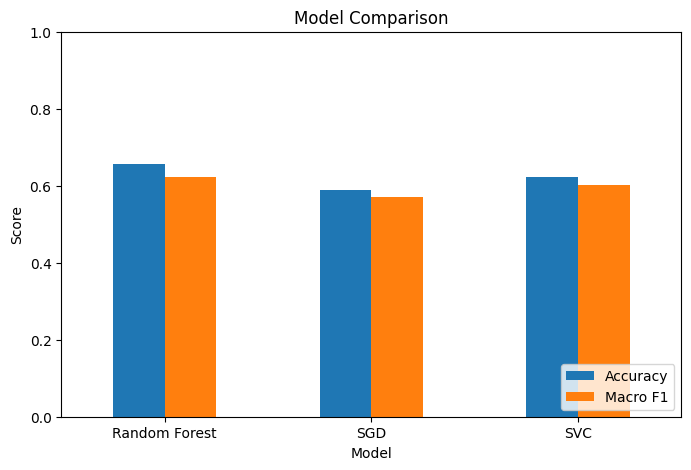

In [13]:
comparison[['Accuracy', 'Macro F1']].plot(kind='bar', figsize=(8, 5))
plt.title('Model Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

## Model Comparison

| Model | Accuracy | Macro Precision | Macro Recall | Macro F1 | Weighted F1 |
|---|---|---|---|---|---|
| Random Forest | 0.6569 | 0.6571 | 0.6084 | 0.6234 | 0.6473 |
| SGD | 0.5882 | 0.5606 | 0.5896 | 0.5709 | 0.5802 |
| SVC | 0.6225 | 0.5911 | 0.6341 | 0.6023 | 0.6167 |

**Random Forest is the best model overall**: it has the highest accuracy (65.7%), the highest macro F1 (0.623) and the best precision. SVC is a close second (macro F1 0.602) and has the best macro recall (0.634), meaning it is the best at *finding* the rarer classes, although it mislabels more wines as it does so. SGD is the weakest on every metric, which is consistent with it being a simple linear model applied to data whose class boundaries are clearly not linear.

The gap between models is modest (about 4-7 accuracy points), and with a test set of only 204 wines, small differences should be treated as indicative rather than conclusive.

## Conclusion

**Best model:** Random Forest performed best on the 3-class wine quality problem, with the highest accuracy (65.7%), macro F1 (0.623) and macro precision (0.657). SVC came second (62.3% accuracy) and was the best at recalling the rarer classes, while SGD was the weakest (58.8%) because a linear boundary cannot separate classes that overlap this much.

**Most suitable for deployment: Random Forest**, for these reasons:
1. It has the best overall and most balanced performance across the Low, Medium and High classes.
2. It needs no delicate tuning to cope with the skewed, outlier-heavy features found in the EDA (chlorides, residual sugar, sulphates), because trees are not affected by feature scale or skew.
3. It is interpretable: the feature importance chart shows that alcohol, sulphates and volatile acidity drive its predictions, which lets a winemaker check that the model's logic matches chemical common sense.
4. It is the heaviest of the three models to train, but at this data size the cost is negligible.

SVC would be the better choice only if the priority were to catch as many High-quality wines as possible (recall 0.70 vs 0.48), and the business could tolerate more false alarms.

**Key findings:**
- Alcohol is the strongest predictor of quality, and volatile acidity the strongest negative one.
- The Medium class (score 6) is hardest for every model: its chemistry overlaps with both neighbours, so most errors are Medium wines predicted as Low, while Low and High are almost never confused with each other.
- Handling data quality mattered: removing 125 duplicate rows prevented identical wines from appearing in both the training and test sets, and stratified splitting plus `class_weight='balanced'` reduced the effect of class imbalance.

**Limitations:** An accuracy of about 66% means this model is not reliable enough to make wine quality decisions on its own. The dataset is small (1,018 wines after de-duplication) and the test set has only 27 High wines, so the results carry noticeable uncertainty. Grouping the scores into three classes also discards the finer distinction between, for example, scores 7 and 8.

**Real-world use:** the model is best used as a **screening or decision-support tool**, for example to flag batches that are likely to be low quality for closer human tasting, rather than to replace expert judgement.

**Next steps to improve it:** tune hyperparameters with cross-validation, try oversampling techniques such as SMOTE for the High class, add more wines (for example by combining the red and white datasets), and test gradient boosting models.